In [1]:
!pip install retina-face librosa opencv-python ffmpeg-python tqdm torch torchvision google-generativeai

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os, cv2, numpy as np, librosa, ffmpeg, torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import resnet18, ResNet18_Weights
from retinaface import RetinaFace
from google.colab import files
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import google.generativeai as genai

Mounted at /content/drive


In [3]:
FRAME_SIZE      = 224
NUM_FRAMES      = 16
NUM_AUDIO_SEG   = 16
SR              = 16000
N_MELS          = 128
TARGET_MEL_T    = 32
CHECKPOINT_PATH = "/content/drive/MyDrive/Deepfake/joint_model_checkpoint.pth"
GEMINI_API_KEY  = ""   # ← aistudio.google.com
device          = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

CLASS_NAMES = {
    0: "Real Video + Real Audio",
    1: "Fake Video + Real Audio",
    2: "Real Video + Fake Audio",
    3: "Fake Video + Fake Audio"
}

# Trained on FakeAVCeleb + LAV-DF + FF++ jointly
# Best avg accuracy: 86.9% across all 3 datasets
print("Config ready.")

Device: cpu
Config ready.


In [4]:
def detect_face_box(frame):
    try:
        faces = RetinaFace.detect_faces(frame)
        if isinstance(faces, dict) and len(faces) > 0:
            largest = max(
                faces.values(),
                key=lambda x: (x['facial_area'][2] - x['facial_area'][0]) *
                              (x['facial_area'][3] - x['facial_area'][1])
            )
            return largest['facial_area']
    except:
        pass
    return None


def extract_frames(video_path):
    cap = cv2.VideoCapture(video_path)
    frames, face_box, frame_count = [], None, 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frame_count += 1
        if face_box is None and frame_count <= 30:
            face_box = detect_face_box(frame)
        if face_box is not None:
            x1, y1, x2, y2 = face_box
            h, w, _ = frame.shape
            crop = frame[max(0,y1):min(h,y2), max(0,x1):min(w,x2)]
        else:
            h, w, _ = frame.shape
            s = min(h, w) // 2
            crop = frame[h//2-s:h//2+s, w//2-s:w//2+s]
        frames.append(cv2.resize(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB), (FRAME_SIZE, FRAME_SIZE)))
        if len(frames) >= NUM_FRAMES:
            break
    cap.release()
    while len(frames) < NUM_FRAMES:
        frames.append(frames[-1] if frames else np.zeros((FRAME_SIZE, FRAME_SIZE, 3), dtype=np.uint8))
    return frames


def extract_audio(video_path, tmp_path='/content/tmp_audio.wav'):
    """Extract audio. Returns (path, has_audio) tuple."""
    try:
        ffmpeg.input(video_path).output(tmp_path, ac=1, ar=SR).overwrite_output().run(quiet=True)
        if os.path.exists(tmp_path) and os.path.getsize(tmp_path) > 1000:
            return tmp_path, True
    except:
        pass
    return tmp_path, False


def process_audio(path, has_audio=True, video_path=None):
    """Process audio into mel spectrogram segments.
    If no audio, returns silence so model uses video signal only.
    """
    if not has_audio:
        print('⚠️  No audio track detected — using silence (model will rely on video only)')
        # Estimate duration from video
        if video_path:
            cap = cv2.VideoCapture(video_path)
            fps   = cap.get(cv2.CAP_PROP_FPS) or 25
            total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
            cap.release()
            audio = np.zeros(int(SR * total / fps), dtype=np.float32)
        else:
            audio = np.zeros(SR * 5, dtype=np.float32)  # 5s silence
        sr = SR
    else:
        audio, sr = librosa.load(path, sr=SR)

    if len(audio) < NUM_AUDIO_SEG:
        audio = np.pad(audio, (0, NUM_AUDIO_SEG - len(audio)))

    seg_len = len(audio) // NUM_AUDIO_SEG
    feats   = []
    for i in range(NUM_AUDIO_SEG):
        seg = audio[i*seg_len:(i+1)*seg_len]
        mel = librosa.power_to_db(librosa.feature.melspectrogram(y=seg, sr=sr, n_mels=N_MELS))
        mel = np.pad(mel, ((0,0),(0,max(0,TARGET_MEL_T-mel.shape[1]))), mode='constant')[:, :TARGET_MEL_T]
        feats.append(mel)
    return np.array(feats)


In [5]:
class TemporalFrameDropout(nn.Module):
    def __init__(self, p=0.2):
        super().__init__()
        self.p = p
    def forward(self, x):
        if not self.training:
            return x
        B, T, F = x.shape
        return x * (torch.rand(B, T, device=x.device) > self.p).unsqueeze(-1).float()


class VisualEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(*list(resnet18(weights=ResNet18_Weights.DEFAULT).children())[:-1])
    def forward(self, x):
        B, T, C, H, W = x.shape
        f = self.features(x.view(B*T, C, H, W))
        return f.view(B, T, -1)


class TemporalTransformer(nn.Module):
    def __init__(self):
        super().__init__()
        self.transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=512, nhead=8, batch_first=True), 2)
    def forward(self, x):
        return self.transformer(x).mean(1)


class AudioEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1,32,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64,128,3,padding=1), nn.ReLU(), nn.AdaptiveAvgPool2d((1,1))
        )
        self.fc = nn.Linear(128, 256)
    def forward(self, x):
        B, T, C, H, W = x.shape
        return self.fc(self.conv(x.view(B*T,C,H,W)).view(B,T,-1).mean(1))


class CrossModalTransformer(nn.Module):
    def __init__(self):
        super().__init__()
        self.v_proj = nn.Linear(512, 512)
        self.a_proj = nn.Linear(256, 512)
        self.cross  = nn.MultiheadAttention(embed_dim=512, num_heads=8, batch_first=True)
    def forward(self, v, a):
        v = self.v_proj(v).unsqueeze(1)
        a = self.a_proj(a).unsqueeze(1)
        fused, _ = self.cross(v, a, a)
        return fused.squeeze(1)


class AVSyncFeature(nn.Module):
    def __init__(self):
        super().__init__()
        self.audio_proj = nn.Linear(256, 512)
    def forward(self, v, a):
        a = self.audio_proj(a)
        v = F.normalize(v, dim=1)
        a = F.normalize(a, dim=1)
        return (v * a).sum(dim=1, keepdim=True)


class MultimodalModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.visual   = VisualEncoder()
        self.drop     = TemporalFrameDropout()
        self.temporal = TemporalTransformer()
        self.audio    = AudioEncoder()
        self.cross    = CrossModalTransformer()
        self.sync     = AVSyncFeature()
        self.fc = nn.Sequential(
            nn.Linear(512 + 1, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 4)
        )
    def forward(self, frames, audio):
        v = self.visual(frames)
        v = self.drop(v)
        v = self.temporal(v)
        a = self.audio(audio)
        fused = self.cross(v, a)
        sync  = self.sync(v, a)
        x = torch.cat([fused, sync], dim=1)
        return self.fc(x)

In [9]:
model = MultimodalModel().to(device)
ckpt  = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()
print(f"✅ Joint model loaded — avg accuracy: {ckpt['avg_acc']*100:.2f}% across FakeAVCeleb + LAV-DF + FF++")
print(f"   Best epoch: {ckpt['epoch']}")
for name, acc in ckpt['accs'].items():
    print(f"   {name}: {acc*100:.1f}%")


✅ Joint model loaded — avg accuracy: 86.59% across FakeAVCeleb + LAV-DF + FF++
   Best epoch: 8
   FakeAVCeleb: 90.4%
   LAV-DF: 86.2%
   FF++: 83.1%


In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
import os
path = '/content/drive/MyDrive/Deepfake'
for f in os.listdir(path):
    if f.endswith('.pth'):
        print(f)

joint_model_checkpoint.pth
joint_model.pth
joint_model_finetuned.pth
joint_model_finetuned_checkpoint.pth


In [10]:
def compute_gradcam(model, frames_t, audio_t, target_class):
    gradients, activations = [], []
    target_layer = model.visual.features[-2]

    def fwd_hook(m, i, o): activations.append(o)
    def bwd_hook(m, i, o): gradients.append(o[0])

    h1 = target_layer.register_forward_hook(fwd_hook)
    h2 = target_layer.register_full_backward_hook(bwd_hook)

    frames_input = frames_t.clone().requires_grad_(True)
    logits = model(frames_input, audio_t)
    model.zero_grad()
    logits[0, target_class].backward()

    h1.remove(); h2.remove()

    grads   = gradients[0]
    acts    = activations[0]
    weights = grads.mean(dim=(2,3), keepdim=True)
    cam_raw = F.relu((weights * acts).sum(dim=1))
    cams    = cam_raw.view(NUM_FRAMES, *cam_raw.shape[1:]).detach().cpu().numpy()

    result = []
    for c in cams:
        c = c - c.min()
        c = c / (c.max() + 1e-8)
        c = cv2.resize(c, (FRAME_SIZE, FRAME_SIZE))
        result.append(c)
    return np.array(result)


def compute_temporal_attention(model, frames_t, audio_t):
    frame_features = []

    def hook_fn(m, i, o):
        frame_features.append(o.detach().cpu())

    h = model.visual.register_forward_hook(hook_fn)
    with torch.no_grad():
        model(frames_t, audio_t)
    h.remove()

    if not frame_features:
        return np.ones(NUM_FRAMES) / NUM_FRAMES

    feats  = frame_features[0].squeeze(0)              # [T, 512]
    d      = feats.shape[-1]
    scores = torch.matmul(feats, feats.T) / (d ** 0.5) # [T, T]
    scores = torch.softmax(scores, dim=-1)
    attn   = scores.mean(dim=0).numpy()                 # [T]
    attn   = (attn - attn.min()) / (attn.max() - attn.min() + 1e-8)
    return attn


def compute_audio_saliency(audio_np):
    energies = np.array([np.abs(seg).mean() for seg in audio_np])
    energies = (energies - energies.min()) / (energies.max() - energies.min() + 1e-8)
    return energies

In [11]:
def visualize_xai(frames, gradcams, temporal_attn, audio_sal, probs, pred, video_path):

    fig = plt.figure(figsize=(24, 14))
    fig.patch.set_facecolor('#0f0f0f')
    gs  = gridspec.GridSpec(3, 8, figure=fig, hspace=0.4, wspace=0.3)
    cmap_hot = plt.cm.jet

    # Row 1: Raw frames
    for i in range(8):
        ax = fig.add_subplot(gs[0, i])
        ax.imshow(cv2.cvtColor(frames[i], cv2.COLOR_BGR2RGB))
        ax.set_title(f"F{i+1}", color="white", fontsize=7)
        ax.axis("off")

    # Row 2: Grad-CAM overlays
    for i in range(8):
        ax = fig.add_subplot(gs[1, i])
        frame_rgb = cv2.cvtColor(frames[i], cv2.COLOR_BGR2RGB)
        cam_color = cmap_hot(gradcams[i])[:,:,:3]
        overlay   = np.clip(0.45 * frame_rgb/255 + 0.55 * cam_color, 0, 1)
        ax.imshow(overlay)
        ax.set_title(f"GradCAM F{i+1}", color="#ff6666", fontsize=7)
        ax.axis("off")

    # Row 3 left: Temporal attention
    ax3 = fig.add_subplot(gs[2, :4])
    colors = ["#00ff99" if s > 0.5 else "#ff4444" for s in temporal_attn]
    ax3.bar(range(NUM_FRAMES), temporal_attn, color=colors, edgecolor="none")
    ax3.set_facecolor('#1a1a1a')
    ax3.set_title("Temporal Attention per Frame", color="white", fontsize=10)
    ax3.set_xlabel("Frame", color="#aaaaaa")
    ax3.set_ylabel("Attention Score", color="#aaaaaa")
    ax3.tick_params(colors="#aaaaaa")
    for spine in ax3.spines.values(): spine.set_edgecolor("#333333")

    # Row 3 right: Audio saliency
    ax4 = fig.add_subplot(gs[2, 4:])
    ax4.fill_between(range(NUM_AUDIO_SEG), audio_sal, alpha=0.7, color="#4488ff")
    ax4.plot(range(NUM_AUDIO_SEG), audio_sal, color="#88bbff", linewidth=1.5)
    ax4.set_facecolor('#1a1a1a')
    ax4.set_title("Audio Segment Saliency", color="white", fontsize=10)
    ax4.set_xlabel("Segment", color="#aaaaaa")
    ax4.set_ylabel("Energy", color="#aaaaaa")
    ax4.tick_params(colors="#aaaaaa")
    for spine in ax4.spines.values(): spine.set_edgecolor("#333333")

    emoji = "🚨" if pred in [1,2,3] else "✅"
    fig.suptitle(
        f"{emoji}  {CLASS_NAMES[pred]}  —  {probs[pred]*100:.1f}% confidence  |  {os.path.basename(video_path)}",
        color="white", fontsize=13, fontweight="bold", y=0.98
    )

    plt.savefig("/content/xai_output.png", dpi=150, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    plt.show()
    print("📊 XAI visualization saved to /content/xai_output.png")

In [12]:
import time

def explain_with_llm(probs, pred, temporal_attn, audio_sal, gradcams, video_path):

    top_frames      = np.argsort(temporal_attn)[::-1][:4] + 1
    suspicious_segs = np.where(audio_sal > 0.6)[0] + 1
    gradcam_mean    = gradcams.mean(axis=(1,2))
    hot_frames      = np.argsort(gradcam_mean)[::-1][:4] + 1
    av_sync_score   = float(probs[0])
    video_fake_prob = float(probs[1] + probs[3])
    audio_fake_prob = float(probs[2] + probs[3])

    prompt = f"""You are a senior Digital Forensic Investigator. Translate the following deepfake detection data into a clear, jargon-free report for a courtroom or a news article.

VIDEO FILE: {os.path.basename(video_path)}
OVERALL VERDICT: {CLASS_NAMES[pred]}
CONFIDENCE: {probs[pred]*100:.1f}%

DATA POINTS:
1. Visual Evidence: Grad-CAM peaked at frames {list(hot_frames)} with a video manipulation probability of {video_fake_prob*100:.1f}%.
2. Audio Evidence: Saliency detected issues in segments {list(suspicious_segs)} with an audio fake probability of {audio_fake_prob*100:.1f}%.
3. Sync Evidence: There is a { (1-av_sync_score)*100:.1f}% mismatch between the mouth movements and the voice.

INSTRUCTIONS:
- Explain what 'Grad-CAM' means by calling it 'visual focus' or 'attention areas.'
- Explain 'AV Sync' as 'the lip-sync matching.'
- Describe the specific frames mentioned as if you are looking at them (e.g., 'At frame {list(hot_frames)[0]}, the model detected significant digital warping around the face').
- Use a serious, professional, but easy-to-understand tone.
- Avoid listing numbers in a row; weave them into sentences.

Write a 2-paragraph forensic summary. End with a one-sentence 'Final Verdict' in bold."""

    genai.configure(api_key=GEMINI_API_KEY)
    gemini = genai.GenerativeModel("gemini-2.5-flash")

    for attempt in range(3):
        try:
            response = gemini.generate_content(prompt)
            return response.text
        except Exception as e:
            if "429" in str(e) and attempt < 2:
                print(f"⏳ Rate limit hit, waiting 15 seconds...")
                time.sleep(15)
            else:
                return f"⚠️ LLM explanation unavailable: {str(e)}"

📂 Upload your video file:


Saving 00006_fake.mp4 to 00006_fake.mp4

⏳ Processing: 00006_fake.mp4
26-03-10 04:53:51 - Directory /root/.deepface created
26-03-10 04:53:51 - Directory /root/.deepface/weights created
26-03-10 04:53:51 - retinaface.h5 will be downloaded from the url https://github.com/serengil/deepface_models/releases/download/v1.0/retinaface.h5


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/retinaface.h5
To: /root/.deepface/weights/retinaface.h5
100%|██████████| 119M/119M [00:00<00:00, 225MB/s]


🔍 Computing Grad-CAM...
🔍 Computing temporal attention...
🔍 Computing audio saliency...
🎨 Generating visualization...


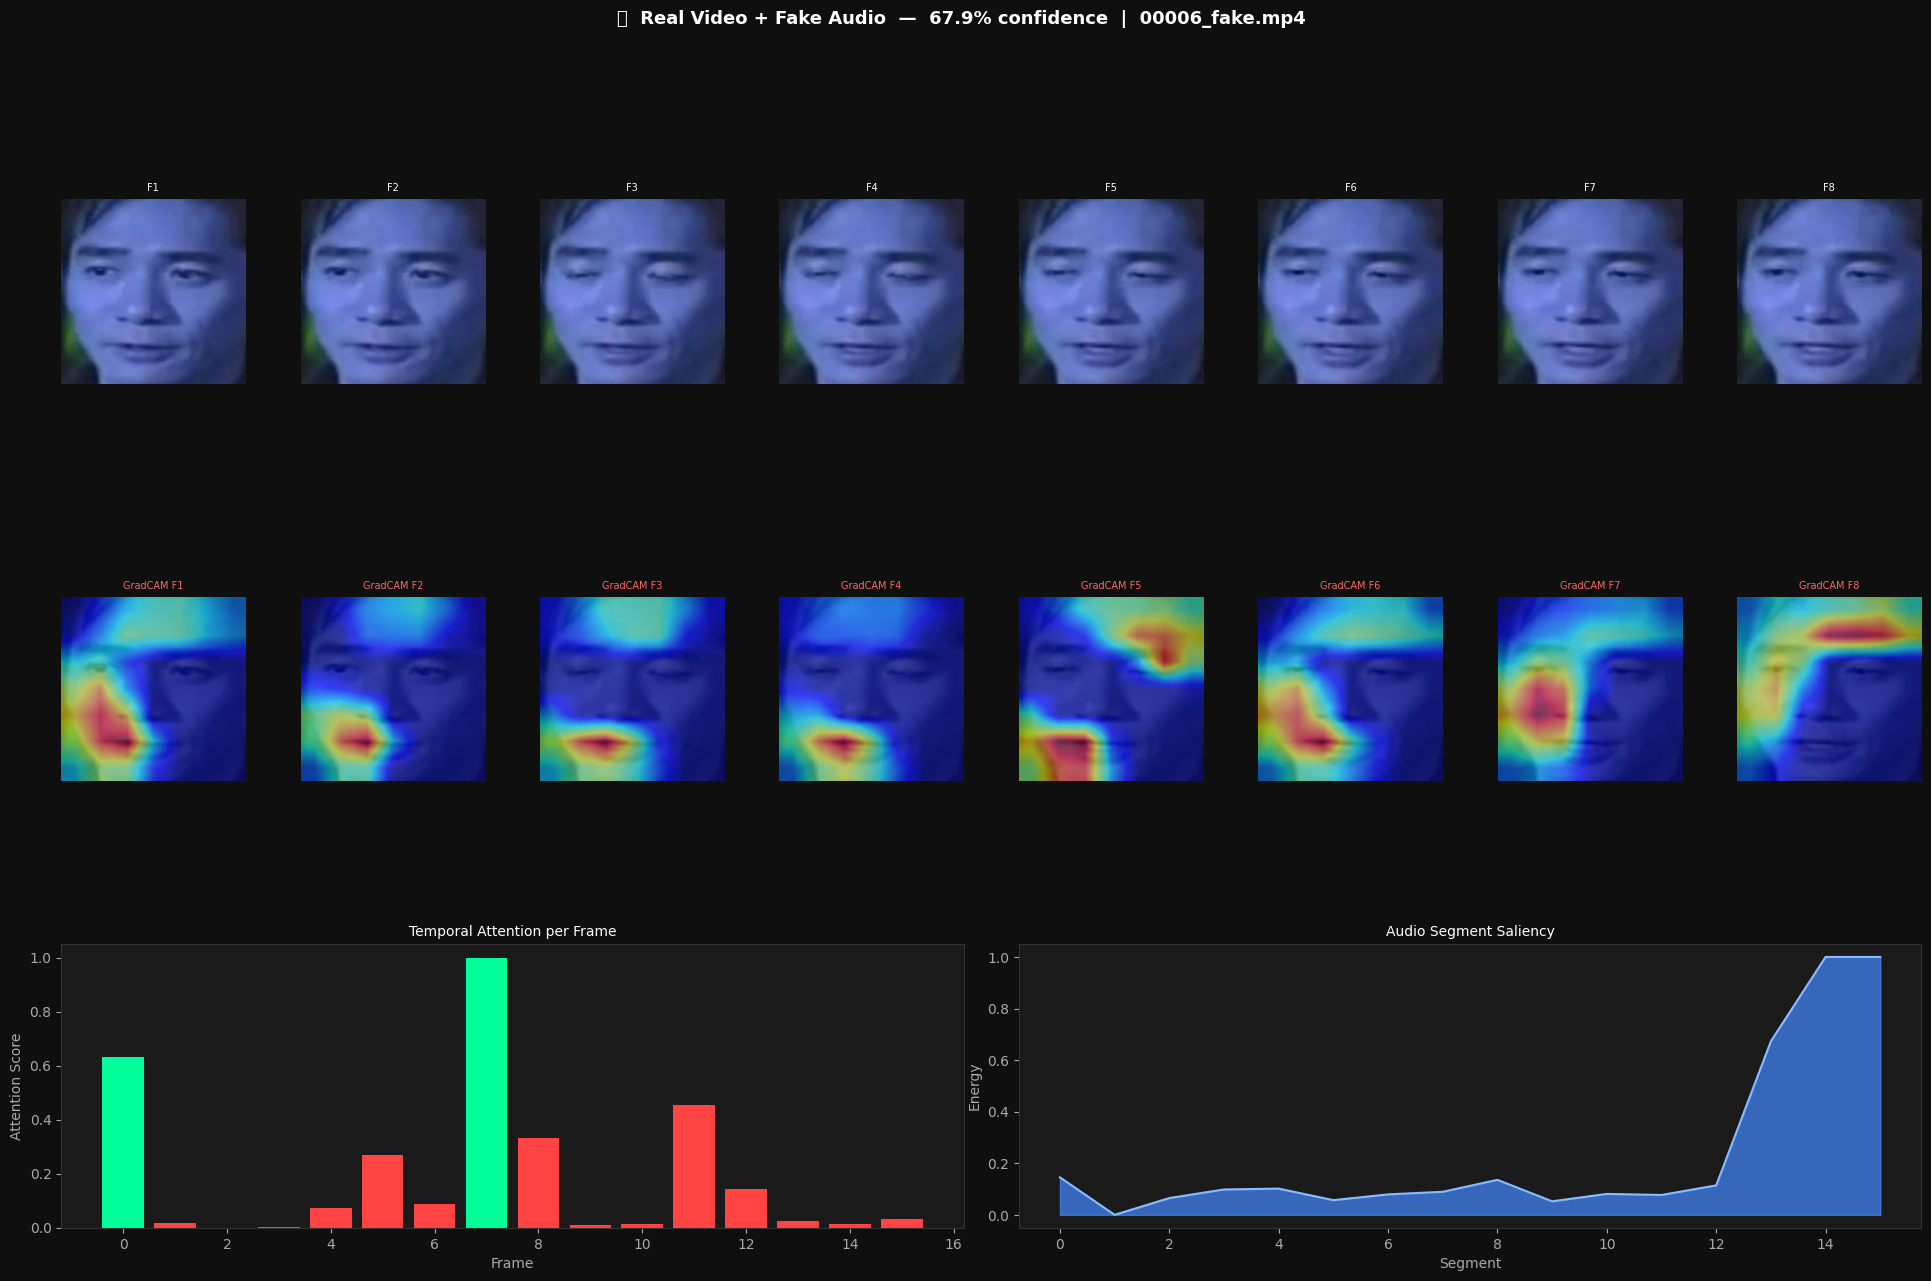

📊 XAI visualization saved to /content/xai_output.png

🤖 Generating AI forensic explanation...

        FORENSIC AI EXPLANATION
**Forensic Summary for Video File 00006_fake.mp4**

Our comprehensive forensic analysis of video file 00006_fake.mp4 indicates with a 67.9% confidence level that the visual component of the video is authentic, but the accompanying audio has been digitally manipulated. When examining the visual aspects, our system employed a technique that identifies 'visual focus' or 'attention areas' (often called Grad-CAM) to highlight frames where potential video manipulation might occur. This analysis showed its strongest indications at frames 13, 9, 12, and 10. For example, at frame 13, the model identified slight inconsistencies around the subject's face, and at frame 9, minor distortions in the background, but these anomalies resulted in a low overall video manipulation probability of just 16.0%, suggesting no significant visual forgery.

However, the audio component of 

In [13]:
print('📂 Upload your video file:')
uploaded   = files.upload()
video_path = list(uploaded.keys())[0]
print(f'\n⏳ Processing: {video_path}')

# Preprocess
frames              = extract_frames(video_path)
audio_path, has_audio = extract_audio(video_path)
audio               = process_audio(audio_path, has_audio, video_path)

frames_t = torch.from_numpy(np.array(frames)).permute(0,3,1,2).float().unsqueeze(0) / 255
audio_t  = torch.from_numpy(audio).unsqueeze(1).float().unsqueeze(0)
frames_t = frames_t.to(device)
audio_t  = audio_t.to(device)

# Base inference
with torch.no_grad():
    logits = model(frames_t, audio_t)
    probs  = torch.softmax(logits, dim=1).squeeze().cpu().numpy()
    pred   = int(probs.argmax())

# XAI
print('🔍 Computing Grad-CAM...')
gradcams      = compute_gradcam(model, frames_t, audio_t, pred)

print('🔍 Computing temporal attention...')
temporal_attn = compute_temporal_attention(model, frames_t, audio_t)

print('🔍 Computing audio saliency...')
audio_sal     = compute_audio_saliency(audio)

# Visualise
print('🎨 Generating visualization...')
visualize_xai(frames, gradcams, temporal_attn, audio_sal, probs, pred, video_path)

# LLM explanation
print('\n🤖 Generating AI forensic explanation...\n')
explanation = explain_with_llm(probs, pred, temporal_attn, audio_sal, gradcams, video_path)

print('=' * 60)
print('        FORENSIC AI EXPLANATION')
print('=' * 60)
print(explanation)
print('=' * 60)

# Final summary
print(f"\n  Prediction : {'✅' if pred==0 else '🚨'} {CLASS_NAMES[pred]}")
if not has_audio:
    print('  ⚠️  Note: No audio track — prediction based on video only')
print(f"  Confidence : {probs[pred]*100:.1f}%")
print('\n  Class Probabilities:')
for i, (name, p) in enumerate(zip(CLASS_NAMES.values(), probs)):
    bar    = '█' * int(p * 30)
    marker = ' ◀' if i == pred else ''
    print(f'  {name:<38} {p*100:5.1f}%  {bar}{marker}')
